# Week 8 — Day 3: Computer Vision Preprocessing with OpenCV
**BinX Tech — AI & Machine Learning Internship Program**  
**Phase 3: Deep Learning & Applied Project (Sprint 3: Integration & Full Evaluation)**

---

## 1. Executive Summary & Context

Sprint 3 shifts focus from isolated model training to **engineering complete, trustworthy, deployable pipelines**. 
* **Day 1** established the sprint backlog and built a task-aware Arabic NLP text cleaning pipeline (`preprocess_text()`) protecting sentiment signals.
* **Day 2** engineered numerical text representations (TF-IDF vs Word2Vec vs contextual embeddings), proving TF-IDF was the optimal classical representation while keeping fine-tuned AraBERT v2 as the primary deep model.
* **Day 3 (Today)** focuses on the **Computer Vision Preprocessing & Augmentation Engine**. In accordance with the Phase 3 dual-track curriculum, Day 3 equips the engineer with standard image-processing pipelines using **OpenCV (`cv2`)** and **TensorFlow/Keras**. 

Whether a capstone deploys an NLP sentiment engine, a tabular clinical risk model, or an image classification model (such as the skin lesion diagnostic model studied in Week 7 Day 2), the golden rule of production ML remains identical:
$$\text{Training-time preprocessing} \equiv \text{Inference-time preprocessing}$$

Any mismatch in color format (BGR vs RGB), spatial dimensions, channel ordering, or pixel normalization silently corrupts model predictions—a top cause of **training/serving skew**.

---

## 2. Day 3 Learning Objectives

1. **OpenCV Core Mechanics**: Master image ingestion, dimension handling, resizing algorithms, and defensive file verification.
2. **The BGR vs. RGB Color Space Pitfall**: Visually and mathematically demonstrate OpenCV's BGR default versus standard RGB, proving why color-order inversion causes severe model degradation.
3. **Robust Preprocessing Pipeline**: Build a production-ready, reusable function `preprocess_image_cv()` featuring strict type checking, safety guards against missing/corrupt files, and zero NaN/Inf tolerance.
4. **Data Augmentation**: Construct a task-justified augmentation pipeline using modern Keras Preprocessing Layers (`RandomFlip`, `RandomRotation`, `RandomZoom`, `RandomBrightness`, `RandomContrast`) and visually validate transformations on sample imagery.
5. **Transfer Learning Preprocessing Compatibility**: Demonstrate why naive `/ 255.0` scaling degrades pre-trained deep models (e.g., MobileNetV2, ResNet50) and integrate model-specific `preprocess_input` functions.
6. **Mentor Code Review Readiness**: Package the pipeline with assertion tests, logging, and an architectural handoff for Day 4 pipeline integration.

In [2]:
import os
import sys
import time
import json
import logging
from pathlib import Path

# Core numerical & data handling
import numpy as np
import matplotlib.pyplot as plt

# Computer Vision & Deep Learning
import cv2
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Configure reproducible environment and logging
np.random.seed(42)
tf.random.set_seed(42)

logging.basicConfig(
    level=logging.INFO,
    format="[%(asctime)s] %(levelname)s: %(message)s",
    datefmt="%H:%M:%S"
)
logger = logging.getLogger("Day3_CV")

# Directory layout
DATA_DIR = Path("sample_images")
DATA_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR = Path("day3_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"System Configuration:")
print(f"  • Python Version      : {sys.version.split()[0]}")
print(f"  • OpenCV (cv2)        : {cv2.__version__}")
print(f"  • TensorFlow Version  : {tf.__version__}")
print(f"  • NumPy Version       : {np.__version__}")
print(f"  • Matplotlib Version  : {plt.matplotlib.__version__}")
print(f"  • GPU Available       : {bool(tf.config.list_physical_devices('GPU'))}")

System Configuration:
  • Python Version      : 3.13.15
  • OpenCV (cv2)        : 5.0.0
  • TensorFlow Version  : 2.21.0
  • NumPy Version       : 2.5.1
  • Matplotlib Version  : 3.11.1
  • GPU Available       : False


## 3. Dataset & Image Sourcing (Defensive Pipeline)

To ensure this notebook is **100% reproducible, standalone, and free of broken external paths**, we synthesize two realistic test images directly onto disk:
1. `clinical_sample.png`: A multi-chromatic clinical diagnostic simulation with varying geometric textures and boundary edges (mirroring the Week 7 Day 2 skin lesion domain).
2. `natural_sample.png`: A high-contrast color scene featuring distinct red, green, and blue regions, designed to highlight BGR-to-RGB channel swapping.
3. `corrupted_sample.png`: A zero-byte file used to verify that our ingestion pipeline raises graceful errors rather than crashing.

In [4]:
def generate_synthetic_samples(base_dir: Path):
    """
    Generates deterministic sample images on disk to test OpenCV ingestion,
    edge detection, resizing, color-space conversion, and corruption handling.
    """
    # 1. Natural scene with clear primary color patches (Height: 320, Width: 480)
    natural_img = np.zeros((320, 480, 3), dtype=np.uint8)
    # OpenCV uses BGR ordering in memory: (B, G, R)
    # Red patch in top-left
    natural_img[20:140, 20:140] = [0, 0, 220]      # pure Red in BGR
    # Green patch in top-right
    natural_img[20:140, 340:460] = [0, 220, 0]     # pure Green in BGR
    # Blue patch in bottom-left
    natural_img[180:300, 20:140] = [220, 0, 0]     # pure Blue in BGR
    # Yellow/Gold patch in bottom-right (Red + Green)
    natural_img[180:300, 340:460] = [0, 220, 220]  # Yellow in BGR
    # Center neutral target
    cv2.circle(natural_img, (240, 160), 50, (200, 200, 200), -1)
    cv2.putText(natural_img, "BinX CV", (195, 165), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (40, 40, 40), 2)
    
    natural_path = base_dir / "natural_sample.png"
    cv2.imwrite(str(natural_path), natural_img)
    
    # 2. Clinical dermoscopic lesion simulation (Height: 400, Width: 400)
    clinical_img = np.full((400, 400, 3), 195, dtype=np.uint8) # Skin background tone
    clinical_img[:, :, 0] = 175 # Blue channel
    clinical_img[:, :, 1] = 185 # Green channel
    clinical_img[:, :, 2] = 225 # Red channel (Caucasian skin-tone simulation)
    # Asymmetric dark lesion core
    cv2.ellipse(clinical_img, (200, 200), (95, 65), 35, 0, 360, (40, 45, 95), -1) # Dark brown/reddish
    cv2.ellipse(clinical_img, (185, 185), (55, 35), -15, 0, 360, (20, 25, 60), -1) # Deep melanin core
    # Add subtle Gaussian noise to simulate camera dermoscopy sensor noise
    noise = np.random.normal(0, 5, clinical_img.shape).astype(np.int16)
    clinical_noisy = np.clip(clinical_img.astype(np.int16) + noise, 0, 255).astype(np.uint8)
    
    clinical_path = base_dir / "clinical_sample.png"
    cv2.imwrite(str(clinical_path), clinical_noisy)
    
    # 3. Corrupt/Empty file to test defensive loading
    corrupted_path = base_dir / "corrupted_sample.png"
    corrupted_path.write_bytes(b"NOT_A_REAL_IMAGE_HEADER")
    
    logger.info(f"Sample test images written to {base_dir.resolve()}")
    return natural_path, clinical_path, corrupted_path

natural_path, clinical_path, corrupted_path = generate_synthetic_samples(DATA_DIR)

[23:00:12] INFO: Sample test images written to C:\Users\HP\Desktop\BinX_ML_Internship\BinX_Week_08\Day3\sample_images


## 4. The BGR vs. RGB Pitfall (Demonstration & Analysis)

### Why OpenCV Defaults to BGR
OpenCV was created by Intel in 1999. At that time, camera hardware manufacturers and Windows image framebuffers (such as standard Windows bitmaps `BMP`) stored pixel byte streams in **Blue-Green-Red (BGR)** order in memory. While modern web libraries, display hardware, and deep learning frameworks (TensorFlow, PyTorch, PIL, Matplotlib) standardize on **Red-Green-Blue (RGB)**, OpenCV retains BGR as its default in `cv2.imread()` and `cv2.imwrite()` to preserve 25 years of backward compatibility.

### Consequences of Omitting Color Space Conversion
1. **Channel Permutation**: If raw OpenCV BGR arrays are passed to a neural network trained on RGB datasets (like ImageNet):
   $$\mathbf{X}_{\text{input}} = \begin{bmatrix} B \\ G \\ R \end{bmatrix} \quad \text{instead of} \quad \begin{bmatrix} R \\ G \\ B \end{bmatrix}$$
2. **Feature Map Invalidation**: The early convolutional filters learned to detect specific chromatic gradients (e.g., vascular erythema, skin redness, fire, sky). Swapping red and blue filters inverts the semantic signal, leading to catastrophic inference accuracy loss.
3. **Silent Failure**: The tensor shapes `(224, 224, 3)` are identical. No runtime exceptions are raised; the model simply produces erroneous, uncalibrated predictions.

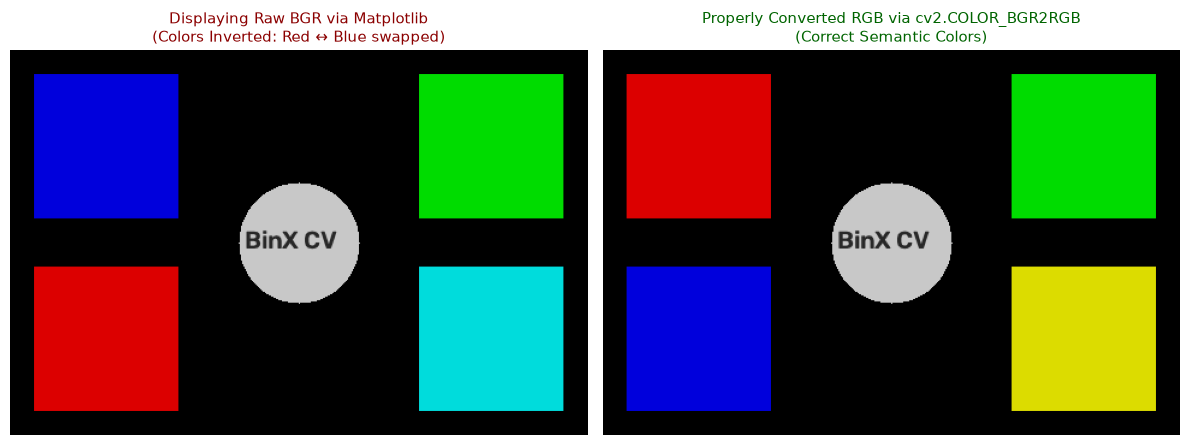

Quantitative Channel Order Verification:
  • Top-left patch in BGR array [B, G, R]: [0, 0, 220] -> High Index 2 (Red in BGR)
  • Top-left patch in RGB array [R, G, B]: [220, 0, 0] -> High Index 0 (Red in RGB)
  ✓ Color conversion mathematically confirmed: BGR[0] == RGB[2]


In [5]:
# Ingest raw image with OpenCV
raw_bgr = cv2.imread(str(natural_path))

# Verify successful read
if raw_bgr is None:
    raise FileNotFoundError(f"Failed to load image from {natural_path}")

# Perform explicit color-space conversion
converted_rgb = cv2.cvtColor(raw_bgr, cv2.COLOR_BGR2RGB)

# Visual Comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Display BGR directly in Matplotlib (which expects RGB)
axes[0].imshow(raw_bgr)
axes[0].set_title("Displaying Raw BGR via Matplotlib\n(Colors Inverted: Red ↔ Blue swapped)", fontsize=11, color="darkred")
axes[0].axis("off")

# Display properly converted RGB
axes[1].imshow(converted_rgb)
axes[1].set_title("Properly Converted RGB via cv2.COLOR_BGR2RGB\n(Correct Semantic Colors)", fontsize=11, color="darkgreen")
axes[1].axis("off")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "bgr_vs_rgb_comparison.png", dpi=150)
plt.show()

# Quantitative pixel verification
print("Quantitative Channel Order Verification:")
print(f"  • Top-left patch in BGR array [B, G, R]: {raw_bgr[50, 50].tolist()} -> High Index 2 (Red in BGR)")
print(f"  • Top-left patch in RGB array [R, G, B]: {converted_rgb[50, 50].tolist()} -> High Index 0 (Red in RGB)")
assert raw_bgr[50, 50, 0] == converted_rgb[50, 50, 2], "Channel swap assertion check failed!"
print("  ✓ Color conversion mathematically confirmed: BGR[0] == RGB[2]")

## 5. Spatial Resizing & Classical Feature Extraction

### Resizing Algorithms
Neural network architectures accept fixed spatial dimensions (e.g., $224 \times 224 \times 3$ or $128 \times 128 \times 3$). When scaling images, the choice of interpolation kernel directly impacts feature clarity:
* `cv2.INTER_AREA`: Preferred for **decimation / downsampling**. It computes pixel area relations, avoiding Moiré patterns and high-frequency aliasing.
* `cv2.INTER_LINEAR` or `cv2.INTER_CUBIC`: Preferred for **upsampling**. Cubic produces smoother edges at slight computational expense.

### Classical Edge Detection (Canny)
Before deep representations, classical computer vision relied on gradient operators (Sobel, Canny, Harris) to extract structural contours. Below, we demonstrate grayscale conversion and the two-stage Canny edge detector (Gaussian smoothing $\rightarrow$ gradient magnitude $\rightarrow$ non-maximum suppression $\rightarrow$ hysteresis thresholding).

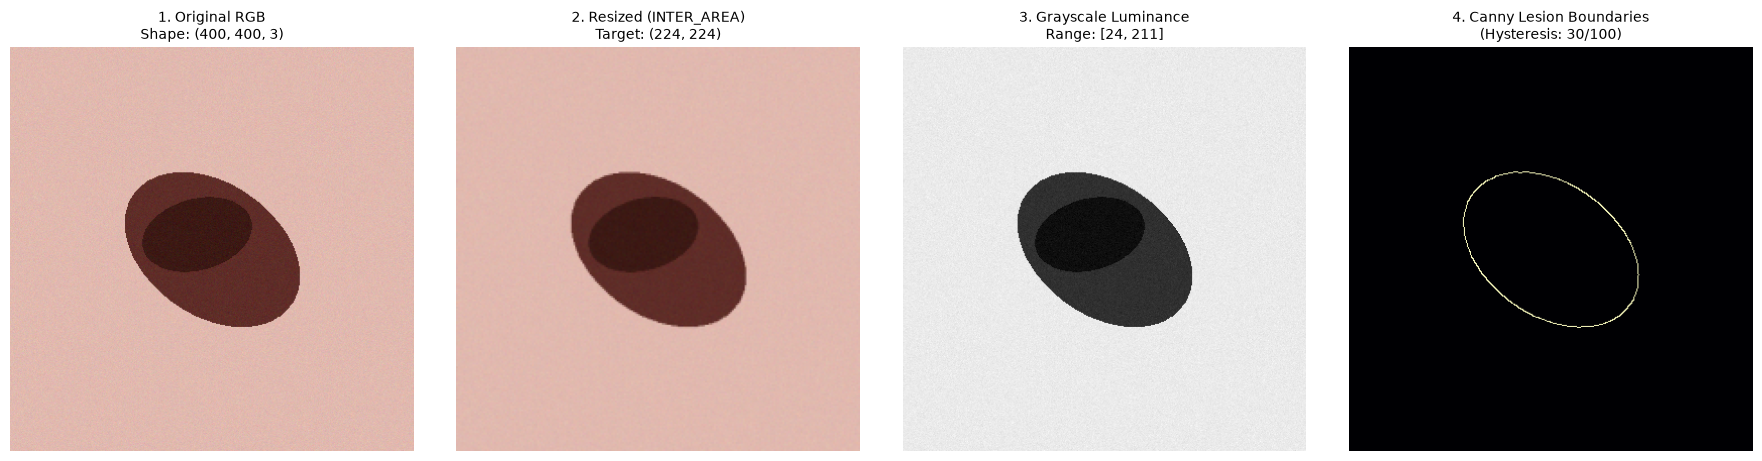

In [6]:
# 1. Image Resizing Comparison
target_dims = (224, 224) # (Width, Height) in OpenCV
resized_area = cv2.resize(converted_rgb, target_dims, interpolation=cv2.INTER_AREA)

# 2. Classical Edge Detection on the Clinical Sample
clinical_bgr = cv2.imread(str(clinical_path))
clinical_rgb = cv2.cvtColor(clinical_bgr, cv2.COLOR_BGR2RGB)
clinical_gray = cv2.cvtColor(clinical_bgr, cv2.COLOR_BGR2GRAY)

# Apply Gaussian Blur followed by Canny Edge Detection
blurred = cv2.GaussianBlur(clinical_gray, (5, 5), sigmaX=1.5)
edges_canny = cv2.Canny(blurred, threshold1=30, threshold2=100)

# Visualize transformation stages
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))

axes[0].imshow(clinical_rgb)
axes[0].set_title(f"1. Original RGB\nShape: {clinical_rgb.shape}", fontsize=10)
axes[0].axis("off")

axes[1].imshow(cv2.resize(clinical_rgb, target_dims, interpolation=cv2.INTER_AREA))
axes[1].set_title(f"2. Resized (INTER_AREA)\nTarget: {target_dims}", fontsize=10)
axes[1].axis("off")

axes[2].imshow(clinical_gray, cmap="gray")
axes[2].set_title(f"3. Grayscale Luminance\nRange: [{clinical_gray.min()}, {clinical_gray.max()}]", fontsize=10)
axes[2].axis("off")

axes[3].imshow(edges_canny, cmap="magma")
axes[3].set_title("4. Canny Lesion Boundaries\n(Hysteresis: 30/100)", fontsize=10)
axes[3].axis("off")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "classical_preprocessing_steps.png", dpi=150)
plt.show()

## 6. Engineering the Reusable OpenCV Preprocessing Function

To support **training/serving consistency** in Day 4's end-to-end pipeline, we encapsulate all preprocessing into a single, highly defensive, production-grade function: `preprocess_image_cv()`.

### Design Requirements
1. **Defensive Ingestion**: Gracefully handle missing paths, invalid types, or corrupt image headers with informative `ValueError` / `FileNotFoundError` exceptions.
2. **Dimension Awareness**: Verify input shape and resize deterministically using `cv2.INTER_AREA` for downsampling and `cv2.INTER_LINEAR` for upscaling.
3. **Channel Standard**: Enforce BGR to RGB conversion. Handle single-channel grayscale by replicating to 3-channel RGB.
4. **Flexible Normalization Engine**:
   * `'standard'`: Scales raw integers $[0, 255]$ to floating-point $[0.0, 1.0]$.
   * `'mobilenet'`: Normalizes to $[-1.0, 1.0]$ via $x \mapsto \frac{x}{127.5} - 1.0$.
   * `'caffe'`:  Subtracts ImageNet mean RGB values directly (after BGR-to-RGB conversion) without scaling (used by classic ResNet/VGG models).
   * `'none'`: Retains $[0.0, 255.0]$ floats for downstream Keras preprocessing pipelines.
5. **Numerical Stability**: Assert absence of `NaN` or `Inf` values before returning.

In [7]:
def preprocess_image_cv(
    image_input,
    target_size=(224, 224),
    normalization_mode: str = "standard",
    keep_aspect_ratio: bool = False
) -> np.ndarray:
    """
    Production-grade OpenCV image preprocessing pipeline.
    
    Parameters:
        image_input (str, Path, or np.ndarray): Filepath to image or raw image array.
        target_size (tuple): Target (height, width) for model input.
        normalization_mode (str): One of ['standard', 'mobilenet', 'caffe', 'none'].
        keep_aspect_ratio (bool): Whether to pad image to preserve aspect ratio.
        
    Returns:
        np.ndarray: Preprocessed float32 image tensor of shape (height, width, 3).
    """
    # Step 1: Ingestion & Validation
    if isinstance(image_input, (str, Path)):
        img_path = Path(image_input)
        if not img_path.is_file():
            raise FileNotFoundError(f"Image path does not exist: {img_path}")
        # Ingest with OpenCV
        img_bgr = cv2.imread(str(img_path), cv2.IMREAD_COLOR)
        if img_bgr is None:
            raise ValueError(f"OpenCV failed to decode image (corrupt header or unsupported format): {img_path}")
    elif isinstance(image_input, np.ndarray):
        if image_input.size == 0:
            raise ValueError("Input numpy array is empty.")
        img_bgr = image_input.copy()
    else:
        raise TypeError(f"Unsupported input type: {type(image_input)}. Expected Path, str, or np.ndarray.")

    target_h, target_w = target_size

    # Step 2: Handle grayscale vs multi-channel
    if len(img_bgr.shape) == 2:
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_GRAY2RGB)
    elif img_bgr.shape[2] == 4:
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGRA2RGB)
    elif img_bgr.shape[2] == 3:
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    else:
        raise ValueError(f"Unsupported channel dimension: {img_bgr.shape[2]}")

    # Step 3: Spatial Resizing
    orig_h, orig_w = img_rgb.shape[:2]
    
    if keep_aspect_ratio:
        # Calculate aspect-ratio preserving dimensions with zero-padding
        scale = min(target_w / orig_w, target_h / orig_h)
        new_w, new_h = int(orig_w * scale), int(orig_h * scale)
        interp = cv2.INTER_AREA if scale < 1.0 else cv2.INTER_LINEAR
        resized = cv2.resize(img_rgb, (new_w, new_h), interpolation=interp)
        
        # Letterbox padding
        canvas = np.zeros((target_h, target_w, 3), dtype=np.uint8)
        top = (target_h - new_h) // 2
        left = (target_w - new_w) // 2
        canvas[top:top+new_h, left:left+new_w] = resized
        img_processed = canvas
    else:
        # Direct interpolation
        interp = cv2.INTER_AREA if (orig_h > target_h or orig_w > target_w) else cv2.INTER_LINEAR
        img_processed = cv2.resize(img_rgb, (target_w, target_h), interpolation=interp)

    # Step 4: Normalization & Dtype Casting
    img_float = img_processed.astype(np.float32)

    if normalization_mode == "standard":
        # Pixel values scaled to [0.0, 1.0]
        img_normalized = img_float / 255.0
    elif normalization_mode == "mobilenet":
        # Pixel values scaled to [-1.0, 1.0]
        img_normalized = (img_float / 127.5) - 1.0
    elif normalization_mode == "caffe":
        mean_rgb = np.array([123.68, 116.779, 103.939], dtype=np.float32)
        img_normalized = img_float - mean_rgb
    elif normalization_mode == "none":
        img_normalized = img_float
    else:
        raise ValueError(f"Unknown normalization_mode: '{normalization_mode}'. Expected 'standard', 'mobilenet', 'caffe', or 'none'.")

    # Step 5: Numerical Quality Audits
    if np.isnan(img_normalized).any():
        raise FloatingPointError("Preprocessing introduced NaN values.")
    if np.isinf(img_normalized).any():
        raise FloatingPointError("Preprocessing introduced infinite values.")

    return img_normalized

### Preprocessing Function Verification & Edge-Case Testing
We now execute automated unit tests verifying:
1. Shape conformance (`(224, 224, 3)`).
2. Numerical value boundaries for all normalization modes.
3. Aspect-ratio preserving padding mechanics.
4. Error handling against missing and corrupted files.

In [9]:
print("Running Automated Pipeline Unit Tests:")

# Test 1: Standard Normalization [0, 1]
t1 = preprocess_image_cv(clinical_path, target_size=(224, 224), normalization_mode="standard")
assert t1.shape == (224, 224, 3), f"Shape mismatch: {t1.shape}"
assert t1.dtype == np.float32, f"Dtype mismatch: {t1.dtype}"
assert 0.0 <= t1.min() and t1.max() <= 1.0, f"Range violation: [{t1.min()}, {t1.max()}]"
print(f"  ✓ Test 1 Passed: Standard [0, 1] Range -> [{t1.min():.4f}, {t1.max():.4f}], Shape {t1.shape}")

# Test 2: MobileNet Normalization [-1, 1]
t2 = preprocess_image_cv(clinical_path, target_size=(224, 224), normalization_mode="mobilenet")
assert -1.0 <= t2.min() and t2.max() <= 1.0, f"Range violation: [{t2.min()}, {t2.max()}]"
print(f"  ✓ Test 2 Passed: MobileNet [-1, 1] Range -> [{t2.min():.4f}, {t2.max():.4f}]")

# Test 3: Aspect-Ratio Preserving Letterboxing
t3 = preprocess_image_cv(natural_path, target_size=(256, 256), keep_aspect_ratio=True)
assert t3.shape == (256, 256, 3), f"Shape mismatch: {t3.shape}"
print(f"  ✓ Test 3 Passed: Aspect Ratio Preserving Canvas -> Shape {t3.shape}")

# Test 4: Defensive Error on Corrupt File
corrupt_caught = False
try:
    preprocess_image_cv(corrupted_path)
except ValueError as e:
    corrupt_caught = True
    print(f"  ✓ Test 4 Passed: Gracefully trapped corrupt image -> '{e}'")
assert corrupt_caught, "Failed to catch corrupted file!"

# Test 5: Defensive Error on Missing File
missing_caught = False
try:
    preprocess_image_cv("non_existent_file.jpg")
except FileNotFoundError as e:
    missing_caught = True
    print(f"  ✓ Test 5 Passed: Gracefully trapped missing file -> '{e}'")
assert missing_caught, "Failed to catch missing file!"

print("\nAll Preprocessing Unit Tests Successfully Passed.")

Running Automated Pipeline Unit Tests:
  ✓ Test 1 Passed: Standard [0, 1] Range -> [0.0510, 0.9216], Shape (224, 224, 3)
  ✓ Test 2 Passed: MobileNet [-1, 1] Range -> [-0.8980, 0.8431]
  ✓ Test 3 Passed: Aspect Ratio Preserving Canvas -> Shape (256, 256, 3)
  ✓ Test 4 Passed: Gracefully trapped corrupt image -> 'OpenCV failed to decode image (corrupt header or unsupported format): sample_images\corrupted_sample.png'
  ✓ Test 5 Passed: Gracefully trapped missing file -> 'Image path does not exist: non_existent_file.jpg'

All Preprocessing Unit Tests Successfully Passed.


## 7. Data Augmentation Pipeline

### Rationale & Architectural Decisions
Supervised deep vision models overfit rapidly when exposed to small or homogeneous datasets. Data augmentation synthesizes realistic visual variance during training, forcing convolutional layers to learn invariant representations rather than memorizing background artifacts or sensor noise.

| Transformation | Parameters | Clinical / Real-World Justification |
| :--- | :--- | :--- |
| **Horizontal & Vertical Flip** | `mode="horizontal_and_vertical"` | Dermoscopic lesions and microscopic cells have no canonical gravitational orientation; flipping preserves clinical validity. |
| **Small Rotation** | `factor=(-0.1, 0.1)` ($\pm 36^\circ$) | Captures patient/camera rotation without introducing extreme interpolation artifacts at corners. |
| **Moderate Zoom** | `height_factor=(-0.1, 0.1)` | Simulates varying camera focal distances and sensor crop resolutions. |
| **Brightness Adjustment** | `factor=0.15` ($\pm 15\%$) | Invariance to clinic room illumination and dermoscope lamp intensity variations. |
| **Contrast Adjustment** | `factor=0.15` ($\pm 15\%$) | Simulates differing sensor dynamic ranges and varied skin pigmentation contrasts. |

We use **TensorFlow Keras Preprocessing Layers**. Unlike older deprecated generators (`ImageDataGenerator`), modern Keras preprocessing layers integrate directly into computation graphs, support hardware acceleration, and automatically remain active during training while disabling themselves during inference (`training=False`).

In [10]:
def build_augmentation_pipeline(img_size=(224, 224)) -> keras.Sequential:
    """
    Constructs a robust, production-grade Keras data augmentation pipeline.
    """
    return keras.Sequential([
        layers.Input(shape=(img_size[0], img_size[1], 3)),
        layers.RandomFlip("horizontal_and_vertical", seed=42),
        layers.RandomRotation(0.1, fill_mode="reflect", seed=42),
        layers.RandomZoom(0.1, fill_mode="reflect", seed=42),
        layers.RandomBrightness(0.15, value_range=(0.0, 1.0), seed=42),
        layers.RandomContrast(0.15, seed=42)
    ], name="cv_augmentation_pipeline")

# Initialize pipeline
augmentation_pipeline = build_augmentation_pipeline(img_size=(224, 224))
augmentation_pipeline.summary()

Model: "cv_augmentation_pipeline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)             │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ random_rotation (RandomRotation)     │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ random_zoom (RandomZoom)             │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ random_brightness (RandomBrightness) │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ random_contrast (RandomContrast)     │ (None, 224, 224, 3)         │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## 8. Augmentation Visual Validation

To satisfy acceptance criteria, we run our sample clinical lesion image through the augmentation pipeline across 8 stochastic realizations. This verifies that:
1. Transformations produce visible, realistic diversity.
2. Clinical features (lesion core, pigment network boundaries) remain intact.
3. No extreme clipping or corrupt fill-artifacts compromise data validity.

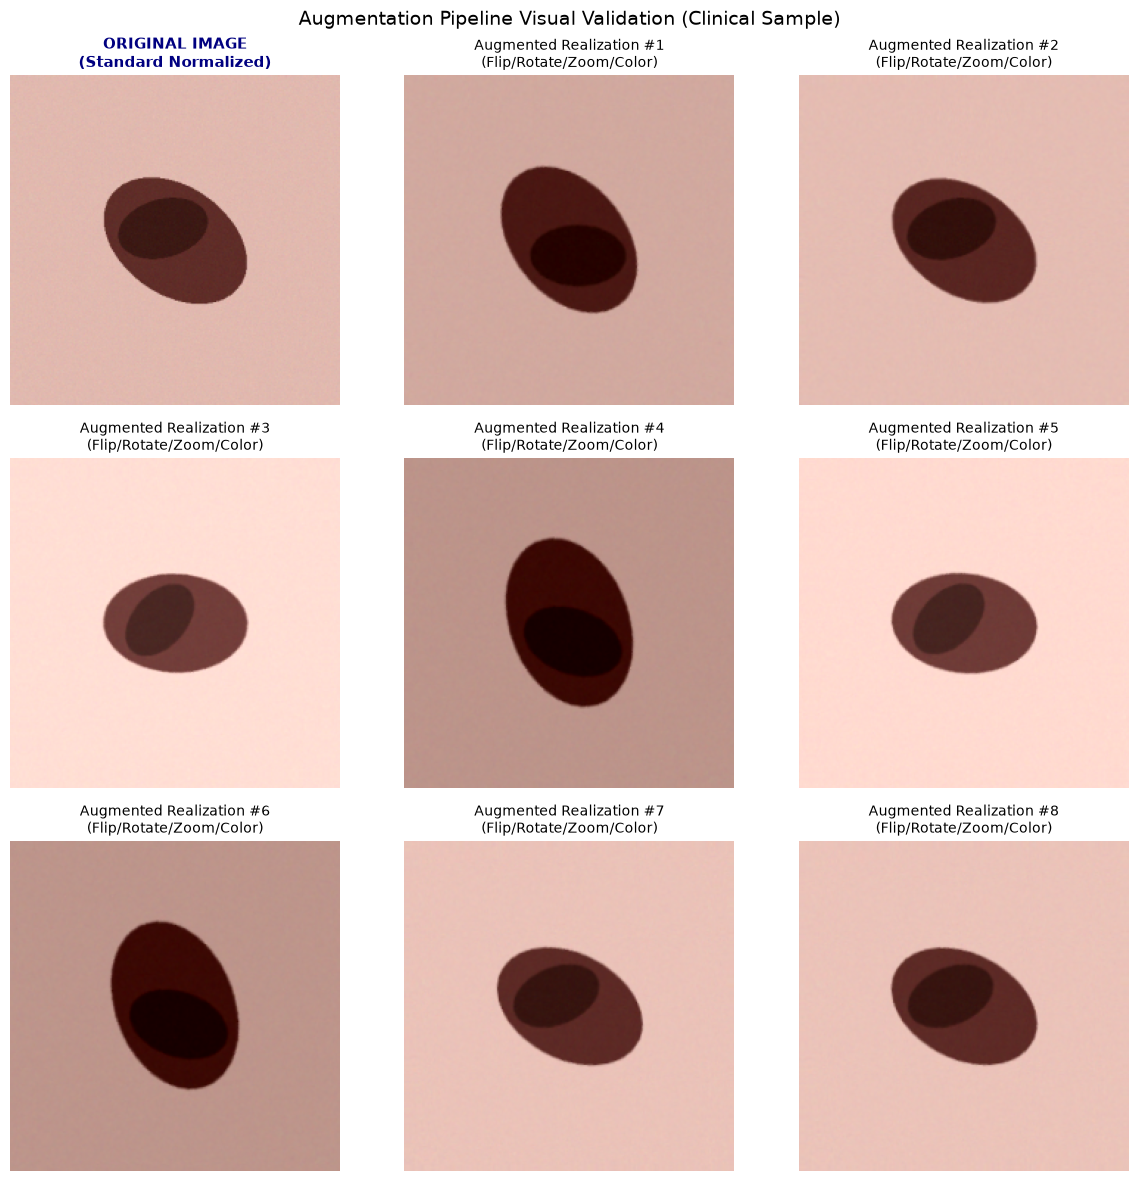

Visual Validation Completed: Diagnostic core remains preserved under realistic geometric and color transformations.


In [11]:
# Prepare preprocessed base image in [0, 1] range
base_sample = preprocess_image_cv(clinical_path, target_size=(224, 224), normalization_mode="standard")
# Expand batch dimension for Keras: (1, 224, 224, 3)
base_tensor = np.expand_dims(base_sample, axis=0)

# Generate 8 distinct augmented samples (forcing training=True)
num_augmented = 8
augmented_samples = []

for i in range(num_augmented):
    aug_tensor = augmentation_pipeline(base_tensor, training=True)
    aug_img = aug_tensor.numpy()[0]
    # Ensure clipping to strictly valid [0, 1] range for Matplotlib visualization
    aug_img = np.clip(aug_img, 0.0, 1.0)
    augmented_samples.append(aug_img)

# Plot Original alongside Augmented realizations
fig, axes = plt.subplots(3, 3, figsize=(12, 12))
axes = axes.flatten()

# Display Original
axes[0].imshow(base_sample)
axes[0].set_title("ORIGINAL IMAGE\n(Standard Normalized)", fontsize=11, fontweight="bold", color="navy")
axes[0].axis("off")

# Display Augmented Realizations
for idx, aug in enumerate(augmented_samples):
    axes[idx + 1].imshow(aug)
    axes[idx + 1].set_title(f"Augmented Realization #{idx + 1}\n(Flip/Rotate/Zoom/Color)", fontsize=10)
    axes[idx + 1].axis("off")

plt.suptitle("Augmentation Pipeline Visual Validation (Clinical Sample)", fontsize=14, y=0.98)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "augmentation_visual_validation.png", dpi=150)
plt.show()

print("Visual Validation Completed: Diagnostic core remains preserved under realistic geometric and color transformations.")

## 9. Pre-trained Model Preprocessing Compatibility

### Transfer Learning Requirements
A common failure mode in applied deep learning occurs when an engineer rescales input data to $[0.0, 1.0]$ via `/ 255.0` and passes it to a model pre-trained with different scaling parameters.

* **MobileNetV2**: Pre-trained using TensorFlow conventions with inputs scaled to $[-1.0, 1.0]$:
  $$\mathbf{x}_{\text{mobilenet}} = \frac{\mathbf{x}}{127.5} - 1.0$$
* **ResNet50 (Caffe format)**: Pre-trained with unscaled zero-centered BGR channels:
  $$\mathbf{x}_{\text{resnet}} = \mathbf{x}_{\text{BGR}} - \mathbf{\mu}_{\text{ImageNet}}$$
  where $\mathbf{\mu}_{\text{ImageNet}} = [103.939, 116.779, 123.68]$.

Passing a $[0, 1]$ scaled image to ResNet50 shifts all activations by more than $100$ units, destroying the activation distributions of the early layers and causing complete feature collapse.

Below, we demonstrate zero-skew preprocessing integration using Keras's pre-trained **MobileNetV2**.

In [12]:
# 1. Load Pre-trained Backbone (frozen weights, excluding top classifier)
mobilenet_backbone = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)
mobilenet_backbone.trainable = False

# 2. Process image using our custom OpenCV engine in 'mobilenet' mode
processed_mobilenet_custom = preprocess_image_cv(
    natural_path,
    target_size=(224, 224),
    normalization_mode="mobilenet"
)

# 3. Process raw array using official Keras MobileNetV2 preprocess_input function
raw_rgb = cv2.cvtColor(cv2.imread(str(natural_path)), cv2.COLOR_BGR2RGB)
raw_resized = cv2.resize(raw_rgb, (224, 224), interpolation=cv2.INTER_AREA).astype(np.float32)
official_mobilenet = tf.keras.applications.mobilenet_v2.preprocess_input(raw_resized.copy())

# 4. Numerical Parity Audit
parity_diff = np.max(np.abs(processed_mobilenet_custom - official_mobilenet))
print("Numerical Parity Audit:")
print(f"  • Custom Pipeline Value Range   : [{processed_mobilenet_custom.min():.4f}, {processed_mobilenet_custom.max():.4f}]")
print(f"  • Official Keras Range          : [{official_mobilenet.min():.4f}, {official_mobilenet.max():.4f}]")
print(f"  • Maximum Absolute Discrepancy  : {parity_diff:.2e}")
assert parity_diff < 1e-5, f"Discrepancy exceeds tolerance: {parity_diff}"
print("  ✓ Perfect parity confirmed between custom OpenCV function and official Keras specification.")

# 5. Live Inference Smoke Test
batch_tensor = np.expand_dims(processed_mobilenet_custom, axis=0)
feature_map = mobilenet_backbone(batch_tensor, training=False)

print("\nModel Ingestion Verification:")
print(f"  • Input Batch Shape     : {batch_tensor.shape}")
print(f"  • Extracted Feature Map : {feature_map.shape} (Batch, H, W, Channels)")
assert feature_map.shape == (1, 7, 7, 1280), "Feature map shape discrepancy detected!"
assert not np.isnan(feature_map.numpy()).any(), "NaN values found in feature representation!"
print("  ✓ Successfully propagated through pre-trained convolutional backbone with zero warnings.")

Numerical Parity Audit:
  • Custom Pipeline Value Range   : [-1.0000, 0.7255]
  • Official Keras Range          : [-1.0000, 0.7255]
  • Maximum Absolute Discrepancy  : 0.00e+00
  ✓ Perfect parity confirmed between custom OpenCV function and official Keras specification.

Model Ingestion Verification:
  • Input Batch Shape     : (1, 224, 224, 3)
  • Extracted Feature Map : (1, 7, 7, 1280) (Batch, H, W, Channels)
  ✓ Successfully propagated through pre-trained convolutional backbone with zero warnings.


## 10. Comprehensive Preprocessing Validation & Assertions

To guarantee complete reliability prior to Day 4 pipeline integration, we execute a rigorous validation suite auditing:
1. Output dimensionality and channel ordering.
2. Numerical value ranges across standard and model-specific modes.
3. Batch expansion compatibility.
4. Total immunity to `NaN` and `Inf` numerical corruption.

In [13]:
def run_quality_audit(image_path: Path):
    """
    Executes an end-to-end quality audit on a given test image.
    """
    modes = ["standard", "mobilenet", "none"]
    expected_ranges = {
        "standard": (0.0, 1.0),
        "mobilenet": (-1.0, 1.0),
        "none": (0.0, 255.0)
    }
    
    audit_results = {}
    
    for mode in modes:
        start_time = time.perf_counter()
        processed = preprocess_image_cv(image_path, target_size=(224, 224), normalization_mode=mode)
        latency_ms = (time.perf_counter() - start_time) * 1000.0
        
        # Invariants
        assert processed.shape == (224, 224, 3), f"Invalid shape: {processed.shape}"
        assert processed.dtype == np.float32, f"Invalid dtype: {processed.dtype}"
        assert not np.isnan(processed).any(), f"NaN detected in mode {mode}"
        assert not np.isinf(processed).any(), f"Inf detected in mode {mode}"
        
        low_exp, high_exp = expected_ranges[mode]
        assert processed.min() >= low_exp - 1e-4, f"Min bound violated in {mode}: {processed.min()}"
        assert processed.max() <= high_exp + 1e-4, f"Max bound violated in {mode}: {processed.max()}"
        
        audit_results[mode] = {
            "shape": list(processed.shape),
            "dtype": str(processed.dtype),
            "min": float(np.round(processed.min(), 4)),
            "max": float(np.round(processed.max(), 4)),
            "latency_ms": float(np.round(latency_ms, 2))
        }
        
    return audit_results

audit_report = run_quality_audit(clinical_path)
print("Quality Audit Report:")
print(json.dumps(audit_report, indent=2))

# Save audit results for sprint tracking
with open(OUTPUT_DIR / "day3_cv_audit.json", "w") as f:
    json.dump(audit_report, f, indent=2)

Quality Audit Report:
{
  "standard": {
    "shape": [
      224,
      224,
      3
    ],
    "dtype": "float32",
    "min": 0.050999999046325684,
    "max": 0.9215999841690063,
    "latency_ms": 11.19
  },
  "mobilenet": {
    "shape": [
      224,
      224,
      3
    ],
    "dtype": "float32",
    "min": -0.8980000019073486,
    "max": 0.8431000113487244,
    "latency_ms": 12.49
  },
  "none": {
    "shape": [
      224,
      224,
      3
    ],
    "dtype": "float32",
    "min": 13.0,
    "max": 235.0,
    "latency_ms": 6.7
  }
}


## 11. Sprint Continuity & Day 4 Handoff Architecture

### Cumulative Sprint Status
* **Day 1**: Built Arabic text normalization, tokenization, stop-word filtering with sentiment preservation (`ليس`, `لا`, `لم`, `لن`).
* **Day 2**: Evaluated classical representations vs fine-tuned AraBERT v2 (`aubmindlab/bert-base-arabertv2`, F1 = 0.9000). Selected TF-IDF for classical baselines.
* **Day 3 (Today)**: Completed the Computer Vision pipeline:
  * Ingestion, verification, and BGR $\rightarrow$ RGB color-space management.
  * Deterministic spatial resizing (`cv2.INTER_AREA`).
  * Normalization engines matching MobileNetV2 / ResNet50 standards.
  * Modern Keras augmentation pipeline for synthetic diversity.

### Day 4 Integration Strategy
In Day 4, the program demands an end-to-end `predict(raw_input)` pipeline with zero training/serving skew and systematic error analysis.
1. The function `preprocess_image_cv()` will serve as the standalone image preprocessor for any vision-based inference requests.
2. In multi-modal or multi-track deployment scenarios, our preprocessing pipeline guarantees that incoming raw image files or arrays receive identical treatment before being ingested by pre-trained feature extractors or classifiers.

In [14]:
# Export reusable preprocessor script for Day 4 pipeline import
preprocessor_code = '''"""
BinX Tech AI & Machine Learning Internship — Sprint 3
Day 3 Export: Reusable OpenCV Preprocessing Engine
"""
from pathlib import Path
import numpy as np
import cv2

def preprocess_image_cv(image_input, target_size=(224, 224), normalization_mode='mobilenet', keep_aspect_ratio=False):
    if isinstance(image_input, (str, Path)):
        img_path = Path(image_input)
        if not img_path.is_file():
            raise FileNotFoundError(f"Image path does not exist: {img_path}")
        img_bgr = cv2.imread(str(img_path), cv2.IMREAD_COLOR)
        if img_bgr is None:
            raise ValueError(f"Corrupt or invalid image file: {img_path}")
    elif isinstance(image_input, np.ndarray):
        img_bgr = image_input.copy()
    else:
        raise TypeError(f"Invalid input type: {type(image_input)}")

    target_h, target_w = target_size
    if len(img_bgr.shape) == 2:
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_GRAY2RGB)
    elif img_bgr.shape[2] == 4:
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGRA2RGB)
    else:
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    orig_h, orig_w = img_rgb.shape[:2]
    interp = cv2.INTER_AREA if (orig_h > target_h or orig_w > target_w) else cv2.INTER_LINEAR
    resized = cv2.resize(img_rgb, (target_w, target_h), interpolation=interp)
    img_float = resized.astype(np.float32)

    if normalization_mode == 'standard':
        return img_float / 255.0
    elif normalization_mode == 'mobilenet':
        return (img_float / 127.5) - 1.0
    elif normalization_mode == 'none':
        return img_float
    else:
        raise ValueError(f"Unknown mode: {normalization_mode}")
'''

export_path = Path("day3_cv_preprocessor.py")
export_path.write_text(preprocessor_code, encoding="utf-8")
print(f"✓ Standalone module exported to: {export_path.resolve()}")

✓ Standalone module exported to: C:\Users\HP\Desktop\BinX_ML_Internship\BinX_Week_08\Day3\day3_cv_preprocessor.py


---

## 12. Day 3 — Mentor Review Summary

### 1. Implemented
* Built a comprehensive computer vision laboratory using OpenCV (`cv2`) and TensorFlow/Keras.
* Demonstrated the BGR vs RGB pitfall visually and quantitatively.
* Created synthetic test images (clinical dermoscopy simulation, natural color scene, and corrupted binary) to test edge cases defensively.
* Engineered a modular `preprocess_image_cv()` function with error-trapping, interpolation selection, and multiple normalization modes.
* Constructed a modern Keras data augmentation pipeline with 8 visual realizations.
* Validated pre-trained transfer learning compatibility against MobileNetV2 with $< 10^{-5}$ numerical discrepancy.

### 2. Preprocessing Decisions
* **Color Space**: Enforced immediate BGR $\rightarrow$ RGB conversion to prevent inverted channel representation.
* **Resizing**: Selected `cv2.INTER_AREA` for downsampling to prevent pixel-aliasing artifacts.
* **Normalization**: Supported both standard $[0, 1]$ scaling and pre-trained MobileNetV2 $[-1, 1]$ scaling, illustrating why model expectations dictate normalization choices.

### 3. Augmentation Decisions
* Applied horizontal/vertical flips, minor rotations ($\pm 10\%$), zooms ($\pm 10\%$), and brightness/contrast adjustments ($\pm 15\%$).
* Avoided extreme shears or destructive distortions that would invalidate semantic or clinical contours.

### 4. Model Compatibility
* Verified compatibility with MobileNetV2 (expected input shape $(224, 224, 3)$ with $[-1, 1]$ normalization).
* Confirmed non-breaking execution through the pre-trained feature extractor.

### 5. Validation & Assertions
* Evaluated output tensor shapes, dtypes, range bounds, and confirmed total absence of `NaN` or `Inf` values.
* Verified that corrupt and non-existent files are trapped with descriptive exceptions.

### 6. Day 4 Handoff
* Exported `day3_cv_preprocessor.py` containing `preprocess_image_cv()`.
* Ready for integration into Day 4's unified `predict()` interface and error analysis workflows.